<a href="https://colab.research.google.com/github/sagarkakkar03/Data-science/blob/main/assignment_outliers_missing_tukey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Outlier Detection (Tukey’s Method) & Missing Value Analysis

**Dataset:** `healthcare_spend_100.csv` (100 records)

## Objective
Work with a healthcare spending dataset to:
1. Analyze missing values
2. Detect outliers using **Tukey’s IQR method**
3. Decide when to **remove vs treat** outliers
4. Produce a **cleaned dataset** suitable for modeling

> Focus on *reasoning + EDA*, not just code.


## Dataset Description

The dataset represents **patient-level healthcare spending data**.

### Columns
| Column | Description |
|---|---|
| `patient_id` | Unique patient identifier |
| `age` | Age of patient |
| `visits_per_year` | Number of hospital visits per year |
| `avg_visit_cost` | Average cost per visit |
| `annual_spend` | Total annual healthcare spend |
| `days_admitted` | Total days admitted in a year |
| `insurance_type` | Type of insurance (`Private` / `Govt` / `None`) |


In [1]:
import pandas as pd


# Load dataset (make sure healthcare_spend_100.csv is in the same folder as this notebook)
df = pd.read_csv("healthcare_spend_100.csv")

df.head()


,patient_id,age,visits_per_year,avg_visit_cost,days_admitted,insurance_type,annual_spend
0,53,71.0,5.0,NaN,8,Private,112425.0
1,98,64.0,4.0,NaN,8,Private,51468.0
2,64,79.0,3.0,4593.0,4,Private,33779.0
3,90,50.0,2.0,2384.0,4,Govt,24768.0
4,47,52.0,3.0,1282.0,3,Private,18846.0


---

## Part A: Missing Value Analysis

### Q1.
Identify the **number and percentage of missing values** in each column.

In [2]:
# Your work here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       100 non-null    int64  
 1   age              95 non-null     float64
 2   visits_per_year  95 non-null     float64
 3   avg_visit_cost   95 non-null     float64
 4   days_admitted    100 non-null    int64  
 5   insurance_type   72 non-null     object 
 6   annual_spend     100 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 5.6+ KB


**Drop duplicates**

In [3]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       100 non-null    int64  
 1   age              95 non-null     float64
 2   visits_per_year  95 non-null     float64
 3   avg_visit_cost   95 non-null     float64
 4   days_admitted    100 non-null    int64  
 5   insurance_type   72 non-null     object 
 6   annual_spend     100 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 5.6+ KB


### Q2.
List all column that contain missing values

In [4]:
# Your work here
df.isnull().sum()

,0
patient_id,0
age,5
visits_per_year,5
avg_visit_cost,5
days_admitted,0
insurance_type,28
annual_spend,0


In [10]:
df[df['visits_per_year'].isnull()]

,patient_id,age,visits_per_year,avg_visit_cost,days_admitted,insurance_type,annual_spend
17,85,58.0,NaN,NaN,0,Private,13974.0
28,51,19.0,NaN,2491.0,3,NaN,22473.0
41,76,18.0,NaN,1152.0,3,Private,17304.0
42,50,21.0,NaN,3172.0,5,Private,31344.0
79,7,NaN,NaN,3129.0,4,Private,32516.0


In [11]:
tempDataset = df[~(df['visits_per_year'].isna()) & ~(df['avg_visit_cost'].isna())]
tempDataset

,patient_id,age,visits_per_year,avg_visit_cost,days_admitted,insurance_type,annual_spend
2,64,79.0,3.0,4593.0,4,Private,33779.0
3,90,50.0,2.0,2384.0,4,Govt,24768.0
4,47,52.0,3.0,1282.0,3,Private,18846.0
5,94,54.0,10.0,2898.0,0,NaN,28980.0
6,55,71.0,11.0,2335.0,5,Private,50685.0
...,...,...,...,...,...,...,...
95,15,38.0,2.0,1519.0,3,Private,18038.0
96,43,77.0,6.0,2821.0,3,Govt,31926.0
97,22,77.0,12.0,1876.0,6,NaN,52512.0
98,35,56.0,4.0,1252.0,5,Private,30008.0


Checking if the forula works.

data['visits_per_year'] * data['avg_visit_cost'] + 5000 * data['days_admitted']

In [16]:
for index, data in tempDataset.iterrows():
    if data['visits_per_year'] * data['avg_visit_cost'] + 5000 * data['days_admitted'] != data['annual_spend']:
        print(data)

### Q3.
Which columns **should not** have missing values from a business perspective? Explain why.

patient_id: It should never be null otherwise data is wasteful.
age: It has some merit in Health care industry, Age can help understand diaseases.
Others are important but these are the main

Filling missing values using the formula whenever possible.

In [23]:
for index, data in df.iterrows():
  if pd.isna(data['visits_per_year']) or pd.isna(data['avg_visit_cost']):
    if pd.isna(data['visits_per_year']) and pd.isna(data['avg_visit_cost']):
      continue
    if pd.isna(data['visits_per_year']):
      df['visits_per_year'].loc[index] = (data['annual_spend'] - data['days_admitted']*5000)/(data['avg_visit_cost'])
    else:
      df['avg_visit_cost'].loc[index] = (data['annual_spend'] - data['days_admitted']*5000)/(data['visits_per_year'])

/tmp/ipython-input-3601064411.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['avg_visit_cost'].loc[index] = (data['annual_spend'] - data['days_admitted']*5000)/(data['visits_per_year'])
/tmp/ipython-input-3601064411.py:8: SettingWith

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       100 non-null    int64  
 1   age              95 non-null     float64
 2   visits_per_year  99 non-null     float64
 3   avg_visit_cost   99 non-null     float64
 4   days_admitted    100 non-null    int64  
 5   insurance_type   72 non-null     object 
 6   annual_spend     100 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 5.6+ KB


In [25]:
df.head()

,patient_id,age,visits_per_year,avg_visit_cost,days_admitted,insurance_type,annual_spend
0,53,71.0,5.0,14485.0,8,Private,112425.0
1,98,64.0,4.0,2867.0,8,Private,51468.0
2,64,79.0,3.0,4593.0,4,Private,33779.0
3,90,50.0,2.0,2384.0,4,Govt,24768.0
4,47,52.0,3.0,1282.0,3,Private,18846.0


In [28]:
print('max visits_per_year', df['visits_per_year'].max())

max visits_per_year 30.0


### Q4.
For each column with missing values, decide **one appropriate treatment method** (and justify):
- Mean / Median imputation
- Mode imputation


In [29]:
# Your work here
df['age'].loc[df['age'].isna()] = df['age'].median()
df['visits_per_year'].loc[df['visits_per_year'].isna()] = df['visits_per_year'].median()
df['avg_visit_cost'].loc[df['avg_visit_cost'].isna()] = df['avg_visit_cost'].mean()

/tmp/ipython-input-1669987820.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['age'].loc[df['age'].isna()] = df['age'].median()
/tmp/ipython-input-1669987820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

---

## Part B: Outlier Detection using Tukey’s Method (IQR)

### Q5.
For the following numerical columns, compute **Q1, Q3, and IQR**:
- `age`
- `visits_per_year`
- `avg_visit_cost`
- `annual_spend`
- `days_admitted`

### Q6.
Using Tukey’s rule, identify **lower and upper bounds** for each numerical column.

Formula reminder:
- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

In [ ]:
# Your work here

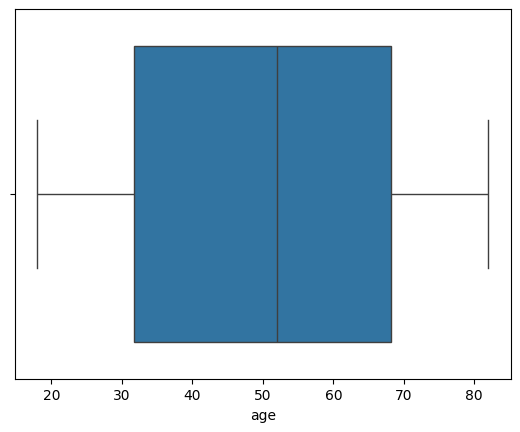

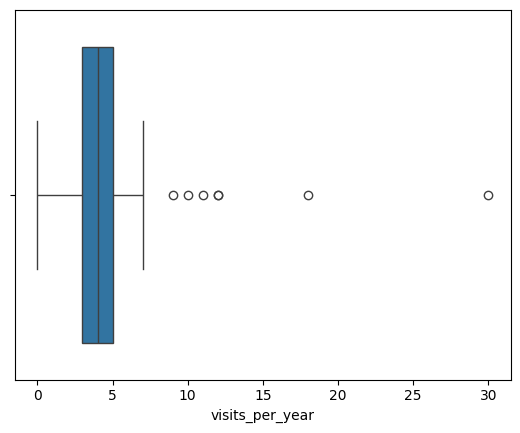

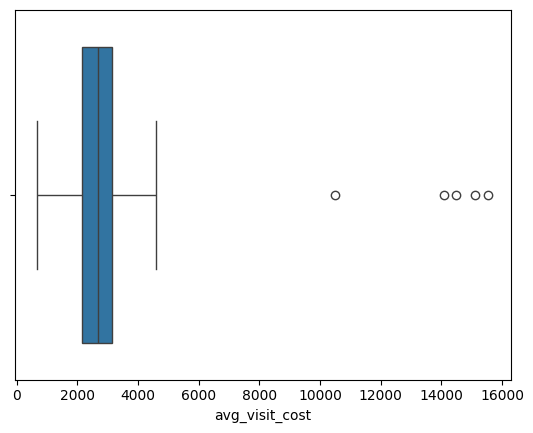

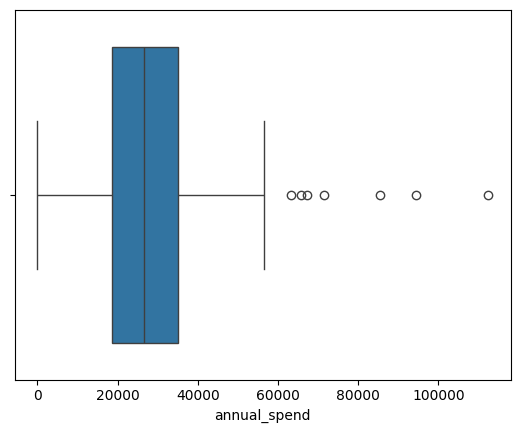

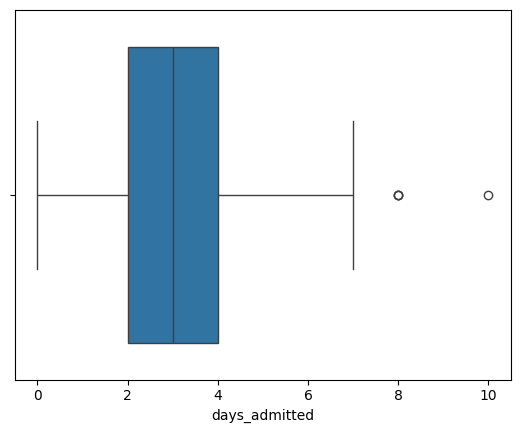

In [32]:
# Your work here
import seaborn as sns
import matplotlib.pyplot as plt
columns = ['age', 'visits_per_year', 'avg_visit_cost', 'annual_spend', 'days_admitted']
for column in columns:
  sns.boxplot(data=df, x=column)
  plt.show()

### Q7.
List the **number of outliers detected per column**.

In [ ]:
# Your work here

### Q8.
Which column(s) show **extreme right-skew behavior**? Support your answer using summary statistics and/or visualizations.

In [ ]:
# Your work here

---

## Part C: Outlier Treatment Strategy

### Q9.
For each column with outliers, decide whether to:
- Remove outliers
- Retain outliers

Provide **business + statistical reasoning**.

In [ ]:
# Your work here

### Q10.
Why might removing outliers in `annual_spend` be **dangerous** for a healthcare sales prediction model?

In [ ]:
# Your work here

---

## Part D: Data Cleaning Execution

### Q11.
Create a **cleaned dataset** by:
- Treating missing values based on your strategy
- Handling outliers using Tukey’s method

Store the final dataset as `df_clean`.

In [ ]:
# Your work here

### Q12.
Compare **before vs after** statistics for:
- Mean
- Median
- Standard deviation

For at least **two numerical columns**.

In [ ]:
# Your work here

---

## Part E: Reflection (Short Answer)

### Q13.
Explain the difference between **outliers as data errors** vs **outliers as valuable signals**.

In [ ]:
# Your work here

### Q14.
In what scenarios should Tukey’s method **not** be used for outlier detection?

In [ ]:
# Your work here